In [1]:
import os
import h5py
import glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
from scipy.integrate import quad
from astropy import constants as const
from scipy.interpolate import interp1d
from scipy.integrate import quad
from scipy.interpolate import CubicSpline

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 200
mpl.rcParams['savefig.dpi'] = 300

# Set universal font properties
plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 14,
})

In [9]:
NU_LYMAN_ALPHA = 2.466e15 # n=2 (Ly_alpha)
NU_LYMAN_BETA  = 2.925e15 # n=3 (Ly_beta)
NU_LYMAN_GAMMA = 3.083e15 # n=4 (Ly_gamma)
NU_LYMAN_DELTA = 3.158e15 # n=5 (Ly_delta)
NU_LYMAN_LIMIT = 3.289e15 # Hz (n=infinity, ionization potential)

NU_LYMAN_ALPHA_He = 9.868725e+15
NU_LYMAN_LIMIT_He = 1.31583e16 # Hz (n=infinity, ionization potential)



# -------------------------------------------------------------
# 1. Load the spectrum table (equivalent to mrt_load_spectrum_table())
# -------------------------------------------------------------
class SpectrumTable:
    def __init__(self, filename):
        self.filename = filename
        self._load()

    def _load(self):
        with h5py.File(self.filename, "r") as f:

            # Dimensions (AREPO: Number_of_freq, N_age, N_metallicity)
            self.Nfreq = int(f["Number_of_freq"][()])
            self.N_age = int(f["N_age"][()]) if "N_age" in f else 1
            self.N_metallicity = int(f["N_metallicity"][()]) if "N_metallicity" in f else 1

            # Energy array
            self.PhotEnergy = f["Energy"][()]  # eV, length Nfreq
            self.freq = f["freq"][()]  # Hz, length Nfreq
            freq = self.freq.reshape(1, 1, self.Nfreq)


            # Luminosity array (erg/s/Hz/Msol)
            Lnu = f["Lnu"][()]  # length Nfreq * N_age * N_metallicity
            Lnu = Lnu.reshape(self.N_metallicity, self.N_age, self.Nfreq)

            # Convert erg/s/Hz/Msol → photons/s/Hz/gram (same as AREPO: divide by PLANCK)
            PLANCK = 6.62607015e-27  # erg*s
            Msol2gram = 1.989e33 # Msol to gram
            m_p = 1.673e-24 # 1 proton mass

            #self.LumPhotons = (Lnu / (PLANCK * self.freq)) * (m_p / Msol2gram)

            # compute epsilon_b
            self.LumPhotons = (Lnu / (PLANCK * freq)) * (m_p / Msol2gram)

            # flatten back to original AREPO-style layout
            self.LumPhotons = self.LumPhotons.reshape(-1)

            #self.LumPhotons = Lnu * m_p / (PLANCK * Msol2gram)

            # Age array (Gyr)
            if self.N_age > 1:
                age_arr = f["age"][()]
                age_arr[age_arr < 1e-6] = 1e-6
                self.AgeGyr = age_arr
                self.LogAge = np.log10(age_arr)
            else:
                self.LogAge = np.array([0.0])
                self.AgeGyr = np.array([0.0])

            # Metallicity array (Z)
            if self.N_metallicity > 1:
                self.Metallicity = f["metallicity"][()]
                self.LogMetallicity = np.log10(self.Metallicity)
            else:
                self.LogMetallicity = np.array([0.0])
                self.Metallicity = np.array([0.0])


        print("Loaded spectrum table:")
        print(f"  Nfreq = {self.Nfreq}")
        print(f"  N_age = {self.N_age}")
        print(f"  N_metallicity = {self.N_metallicity}")

    # -------------------------------------------------------------
    # 2. Return *full spectrum* for given age & metallicity
    # -------------------------------------------------------------
    def full_spectrum(self, i_age, i_metallicity):
        """Returns (Frequency array, LumPhotons array) for specific Z and age indices."""
        # Indexing: Z (outer) -> Age (middle) -> Freq (inner)
        offset = i_metallicity * self.N_age * self.Nfreq + i_age * self.Nfreq
        return self.freq, self.LumPhotons[offset:offset + self.Nfreq]


# -------------------------------------------------------------
# 3. Main Execution
# -------------------------------------------------------------

# Load the table
HDF5_FILEPATH = "/orcd/data/mvogelsb/004/ozier/ZOOM_XL/sharedData/bpass_spectra_bin_chab100_v2.2.1.hdf5"
try:
    spec = SpectrumTable(HDF5_FILEPATH)
except FileNotFoundError:
    print(f"ERROR: Could not find the file at {HDF5_FILEPATH}. Please ensure the path is correct.")
    exit()
except Exception as e:
    print(f"ERROR: Failed to load HDF5 data: {e}")
    exit()


# -------------------------------------------------------------
# 4. Get the spectral distribution function
# -------------------------------------------------------------

def BPASS_SDF_old(Z_target):
    # find index
    iZ = np.where(spec.Metallicity == Z_target)[0][0]

    print("Metallicity index:", iZ)

    all_spectra = []
    all_ages = spec.AgeGyr.copy()

    for i_age in range(spec.N_age):
        freq, lum = spec.full_spectrum(i_age, iZ)
        all_spectra.append(lum)

    all_spectra = np.array(all_spectra)  
    # shape = (N_age, Nfreq)

    dt = np.zeros_like(all_ages)

    dt[0] = all_ages[0]
    dt[1:] = all_ages[1:] - all_ages[:-1]

    # conversion factor
    Gyr_to_sec = 3.15576e16  # seconds in 1 Gyr
    dt_sec = dt * Gyr_to_sec

    # reshape dt so it broadcasts along frequency axis
    dt_sec_2d = dt_sec[:, None]   # shape (N_age, 1)

    # time integration
    N_nu = np.sum(all_spectra * dt_sec_2d, axis=0)

    return freq, N_nu

def BPASS_SDF(Z_target):
    # find index
    iZ = np.where(spec.Metallicity == Z_target)[0][0]
    print("Metallicity index:", iZ)
    all_spectra = []
    all_ages = spec.AgeGyr.copy()
    for i_age in range(spec.N_age):
        freq, lum = spec.full_spectrum(i_age, iZ)
        all_spectra.append(lum)
    all_spectra = np.array(all_spectra)
    # shape = (N_age, Nfreq)

    # log-spaced bin edges (BPASS grid: 0.1 dex in log age)
    log_age_yr = np.log10(all_ages * 1.0e9)      # AgeGyr -> log10(age / yr)
    dlog = np.median(np.diff(log_age_yr))        # 0.1
    edge_hi = 10**(log_age_yr + dlog/2)
    edge_lo = 10**(log_age_yr - dlog/2)
    edge_lo[0] = 0.0                             # first bin runs from t = 0

    # conversion factor
    yr_to_sec = 3.15576e7                        # seconds in 1 yr
    dt_sec = (edge_hi - edge_lo) * yr_to_sec

    # reshape dt so it broadcasts along frequency axis
    dt_sec_2d = dt_sec[:, None]   # shape (N_age, 1)
    # time integration
    N_nu = np.sum(all_spectra * dt_sec_2d, axis=0)
    return freq, N_nu

def STARBURST_SDF(nu, nu_Lya, nu_Lyb, nu_LL, alpha1, alpha2, N_total):
    """
    Continuous piecewise emissivity:
    - slope alpha1 from Lyα → Lyβ
    - slope alpha2 from Lyβ → LL
    - continuous at Lyβ
    - total photons = N_total
    Note: This is a simplified STARBURST spectral distribution function.
    """

    # --- Solve normalization analytically ---

    # First interval integral (without A)
    if alpha1 == 0:
        I1 = np.log(nu_Lyb / nu_Lya)
    else:
        I1 = (nu_Lyb**alpha1 - nu_Lya**alpha1) / alpha1

    # Second interval integral (with continuity factor)
    # continuity factor = (nu_Lyb)^(alpha1 - alpha2)
    factor = nu_Lyb**(alpha1 - alpha2)

    if alpha2 == 0:
        I2 = factor * np.log(nu_LL / nu_Lyb)
    else:
        I2 = factor * (nu_LL**alpha2 - nu_Lyb**alpha2) / alpha2

    # Total integral without A
    I_total = I1 + I2

    # Normalization constant
    A = N_total / I_total

    # --- Build spectrum ---
    epsilon = np.zeros_like(nu)

    mask1 = (nu >= nu_Lya) & (nu < nu_Lyb)
    mask2 = (nu >= nu_Lyb) & (nu <= nu_LL)

    epsilon[mask1] = A * nu[mask1]**(alpha1 - 1)
    epsilon[mask2] = A * factor * nu[mask2]**(alpha2 - 1)

    return epsilon


Loaded spectrum table:
  Nfreq = 100000
  N_age = 34
  N_metallicity = 13


In [10]:
spec.Metallicity

array([1.0e-05, 1.0e-04, 1.0e-03, 2.0e-03, 3.0e-03, 4.0e-03, 6.0e-03,
       8.0e-03, 1.0e-02, 1.4e-02, 2.0e-02, 3.0e-02, 4.0e-02])

In [11]:
spec.AgeGyr

array([1.00000000e-03, 1.25892541e-03, 1.58489319e-03, 1.99526231e-03,
       2.51188643e-03, 3.16227766e-03, 3.98107171e-03, 5.01187234e-03,
       6.30957344e-03, 7.94328235e-03, 1.00000000e-02, 1.25892541e-02,
       1.58489319e-02, 1.99526231e-02, 2.51188643e-02, 3.16227766e-02,
       3.98107171e-02, 5.01187234e-02, 6.30957344e-02, 7.94328235e-02,
       1.00000000e-01, 1.25892541e-01, 1.58489319e-01, 1.99526231e-01,
       2.51188643e-01, 3.16227766e-01, 3.98107171e-01, 5.01187234e-01,
       6.30957344e-01, 7.94328235e-01, 1.00000000e+00, 1.25892541e+00,
       1.58489319e+00, 1.99526231e+00])

Metallicity index: 8
Metallicity index: 2
Metallicity index: 1
Metallicity index: 0


Text(0, 0.5, '$N_\\nu$ [photons Hz$^{-1}$ baryon$^{-1}$]')

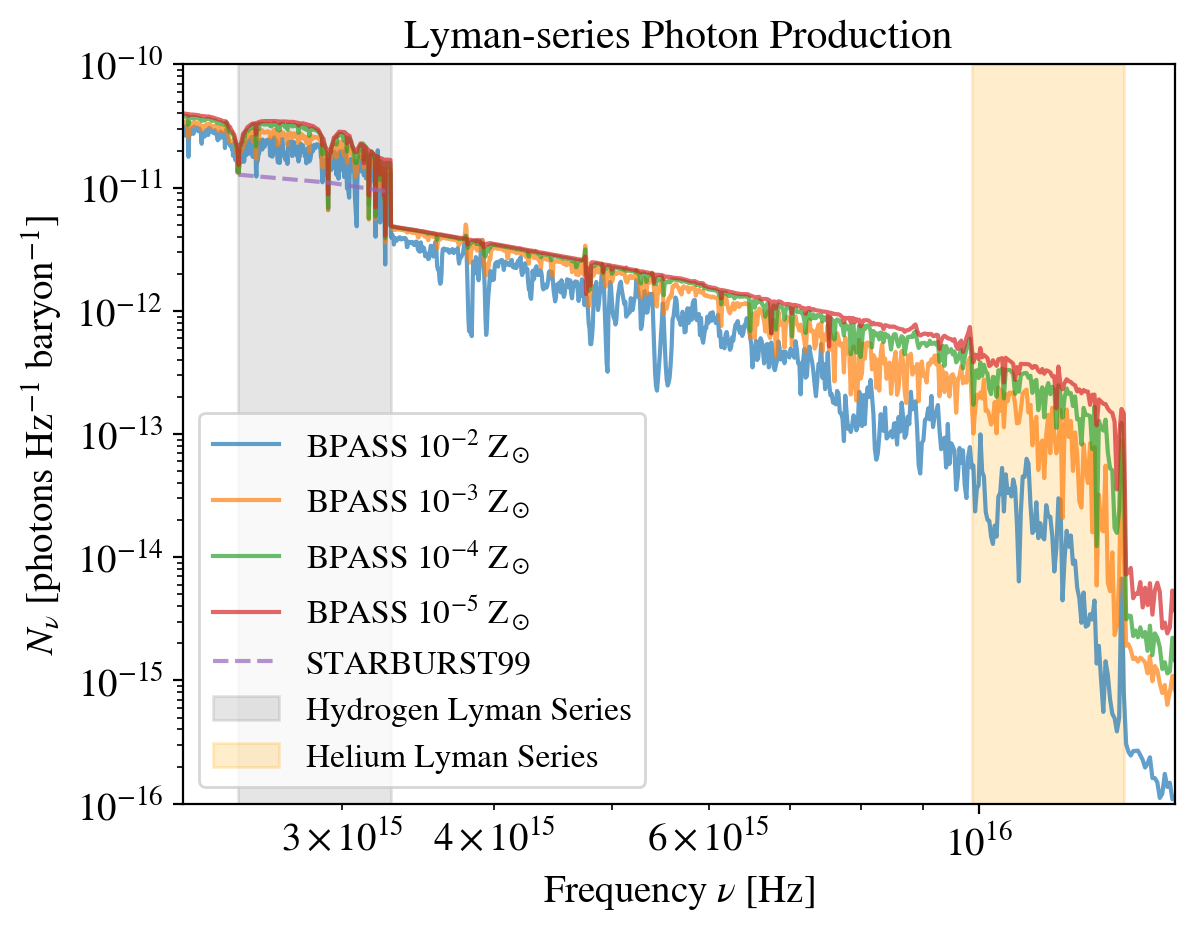

In [12]:
freq, N_nu = BPASS_SDF(1.0e-2)
plt.loglog(freq, N_nu, alpha=0.7, linewidth=1.5, label=r"BPASS 10$^{-2}$ Z$_\odot$")
freq, N_nu = BPASS_SDF(1.0e-3)
plt.loglog(freq, N_nu, alpha=0.7, linewidth=1.5, label=r"BPASS 10$^{-3}$ Z$_\odot$")
freq, N_nu = BPASS_SDF(1.0e-4)
plt.loglog(freq, N_nu, alpha=0.7, linewidth=1.5, label=r"BPASS 10$^{-4}$ Z$_\odot$")
freq, N_nu = BPASS_SDF(1.0e-5)
plt.loglog(freq, N_nu, alpha=0.7, linewidth=1.5, label=r"BPASS 10$^{-5}$ Z$_\odot$")

alpha1 = 0.14
alpha2 = -0.5      # different slope after Lyβ
N_total = 9096

freq = np.linspace(NU_LYMAN_ALPHA, NU_LYMAN_LIMIT, 3000)
N_nu = STARBURST_SDF(freq, NU_LYMAN_ALPHA, NU_LYMAN_BETA, NU_LYMAN_LIMIT, alpha1, alpha2, N_total)

plt.loglog(freq, N_nu, alpha=0.7,  linewidth=1.5, linestyle="--", label="STARBURST99")

# ==============
# SHADED REGION
# ==============
plt.axvspan(NU_LYMAN_ALPHA, NU_LYMAN_LIMIT, color='gray', alpha=0.2, label='Hydrogen Lyman Series')
plt.axvspan(NU_LYMAN_ALPHA_He, NU_LYMAN_LIMIT_He, color='orange', alpha=0.2, label='Helium Lyman Series')


# Hydrogen
#plt.xlim(NU_LYMAN_ALPHA*0.95, NU_LYMAN_LIMIT*1.05) # Lyman series
#plt.ylim(1.0e-12, 1.0e-10)

# Helium
#plt.xlim(NU_LYMAN_ALPHA_He*0.95, NU_LYMAN_LIMIT_He*1.1) # Lyman series
#plt.ylim(1.0e-16, 1.0e-12)

# Both
plt.xlim(NU_LYMAN_ALPHA*0.9, NU_LYMAN_LIMIT_He*1.1) # Lyman series
plt.ylim(1.0e-16, 1.0e-10)

plt.legend(loc="lower left", fontsize=12)

plt.title(r'Lyman-series Photon Production', fontsize=15)
plt.xlabel(r'Frequency $\nu$ [Hz]', fontsize=14)
plt.ylabel(r'$N_\nu$ [photons Hz$^{-1}$ baryon$^{-1}$]',fontsize=14)


Metallicity index: 0
Metallicity index: 1
Metallicity index: 2
Metallicity index: 3
Metallicity index: 4
Metallicity index: 5
Metallicity index: 6
Metallicity index: 7
Metallicity index: 8
Metallicity index: 9


Text(0, 0.5, '$N_\\nu$ [photons Hz$^{-1}$ baryon$^{-1}$]')

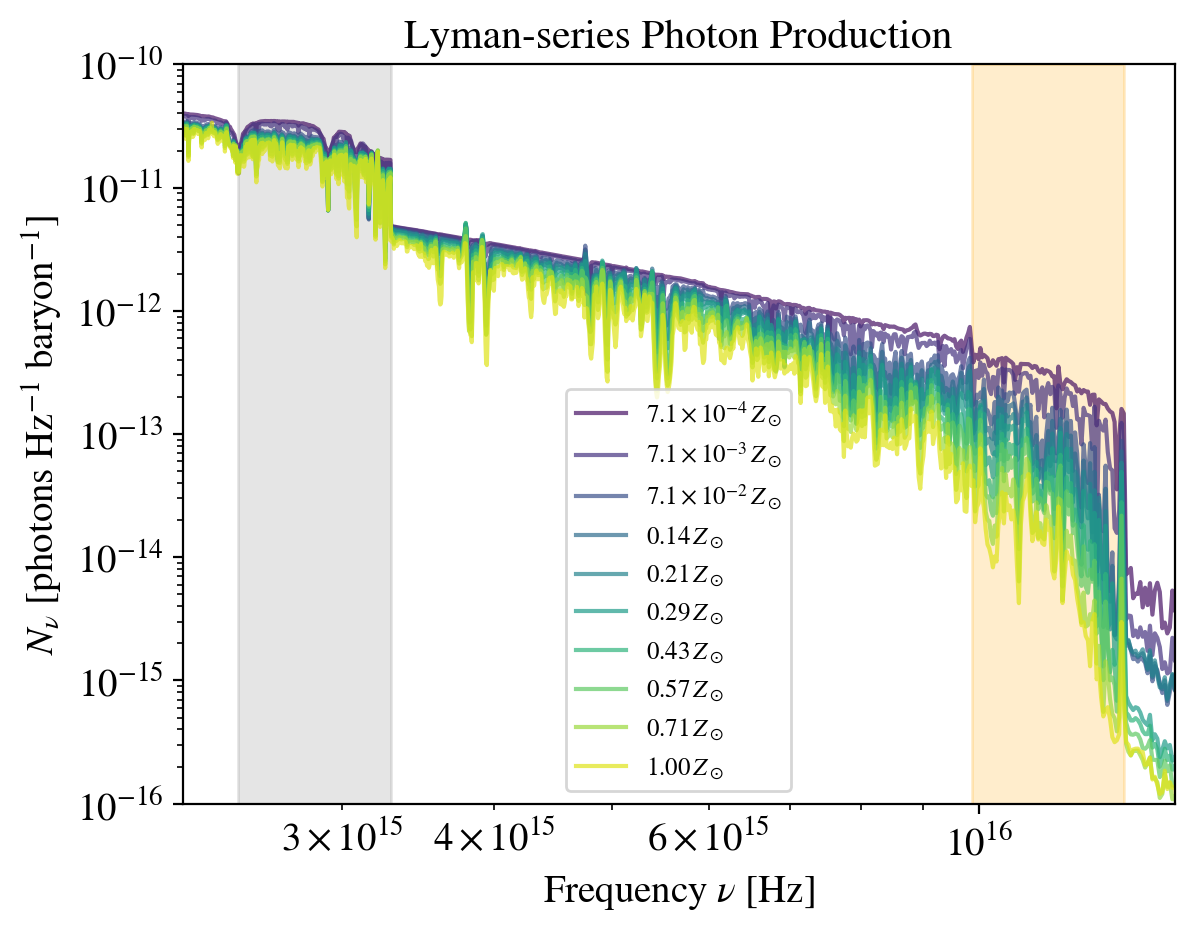

In [13]:
# ---- CHANGED: grid + solar normalisation ----------------------------
Z_SUN = 1.4e-2          # BPASS z014, consistent with Asplund+2009
Z_GRID = [1.0e-5, 1.0e-4, 1.0e-3, 2.0e-3, 3.0e-3,
          4.0e-3, 6.0e-3, 8.0e-3, 1.0e-2, 1.4e-2]

def zlabel(Z):
    r = Z / Z_SUN
    if r >= 0.1:
        return rf"${r:.2f}\,Z_\odot$"
    e = int(np.floor(np.log10(r)))
    return rf"${r/10**e:.1f}\times10^{{{e}}}\,Z_\odot$"

colors = plt.cm.viridis(np.linspace(0.05, 0.95, len(Z_GRID)))

for Z, c in zip(Z_GRID, colors):
    freq, N_nu = BPASS_SDF(Z)
    plt.loglog(freq, N_nu, alpha=0.7, linewidth=1.5, color=c, label=zlabel(Z))
# ---------------------------------------------------------------------

alpha1 = 0.14
alpha2 = -0.5      # different slope after Lyβ
N_total = 9096
freq = np.linspace(NU_LYMAN_ALPHA, NU_LYMAN_LIMIT, 3000)
N_nu = STARBURST_SDF(freq, NU_LYMAN_ALPHA, NU_LYMAN_BETA, NU_LYMAN_LIMIT, alpha1, alpha2, N_total)
#plt.loglog(freq, N_nu, alpha=0.7, linewidth=1.5, linestyle="--", label="STARBURST99")


# ==============
# SHADED REGION
# ==============
plt.axvspan(NU_LYMAN_ALPHA, NU_LYMAN_LIMIT, color='gray', alpha=0.2)#, label='Hydrogen Lyman Series')
plt.axvspan(NU_LYMAN_ALPHA_He, NU_LYMAN_LIMIT_He, color='orange', alpha=0.2)#, label='Helium Lyman Series')


# Hydrogen
#plt.xlim(NU_LYMAN_ALPHA*0.95, NU_LYMAN_LIMIT*1.05) # Lyman series
#plt.ylim(1.0e-12, 1.0e-10)

# Helium
#plt.xlim(NU_LYMAN_ALPHA_He*0.95, NU_LYMAN_LIMIT_He*1.1) # Lyman series
#plt.ylim(1.0e-16, 1.0e-12)

# Both
plt.xlim(NU_LYMAN_ALPHA*0.9, NU_LYMAN_LIMIT_He*1.1) # Lyman series
plt.ylim(1.0e-16, 1.0e-10)

plt.legend(loc="lower center", fontsize=9)

plt.title(r'Lyman-series Photon Production', fontsize=15)
plt.xlabel(r'Frequency $\nu$ [Hz]', fontsize=14)
plt.ylabel(r'$N_\nu$ [photons Hz$^{-1}$ baryon$^{-1}$]',fontsize=14)


Metallicity index: 0
Metallicity index: 1
Metallicity index: 2
Metallicity index: 3
Metallicity index: 4
Metallicity index: 5
Metallicity index: 6
Metallicity index: 7
Metallicity index: 8
Metallicity index: 9


Text(0, 0.5, '$N_\\nu$ [photons Hz$^{-1}$ baryon$^{-1}$]')

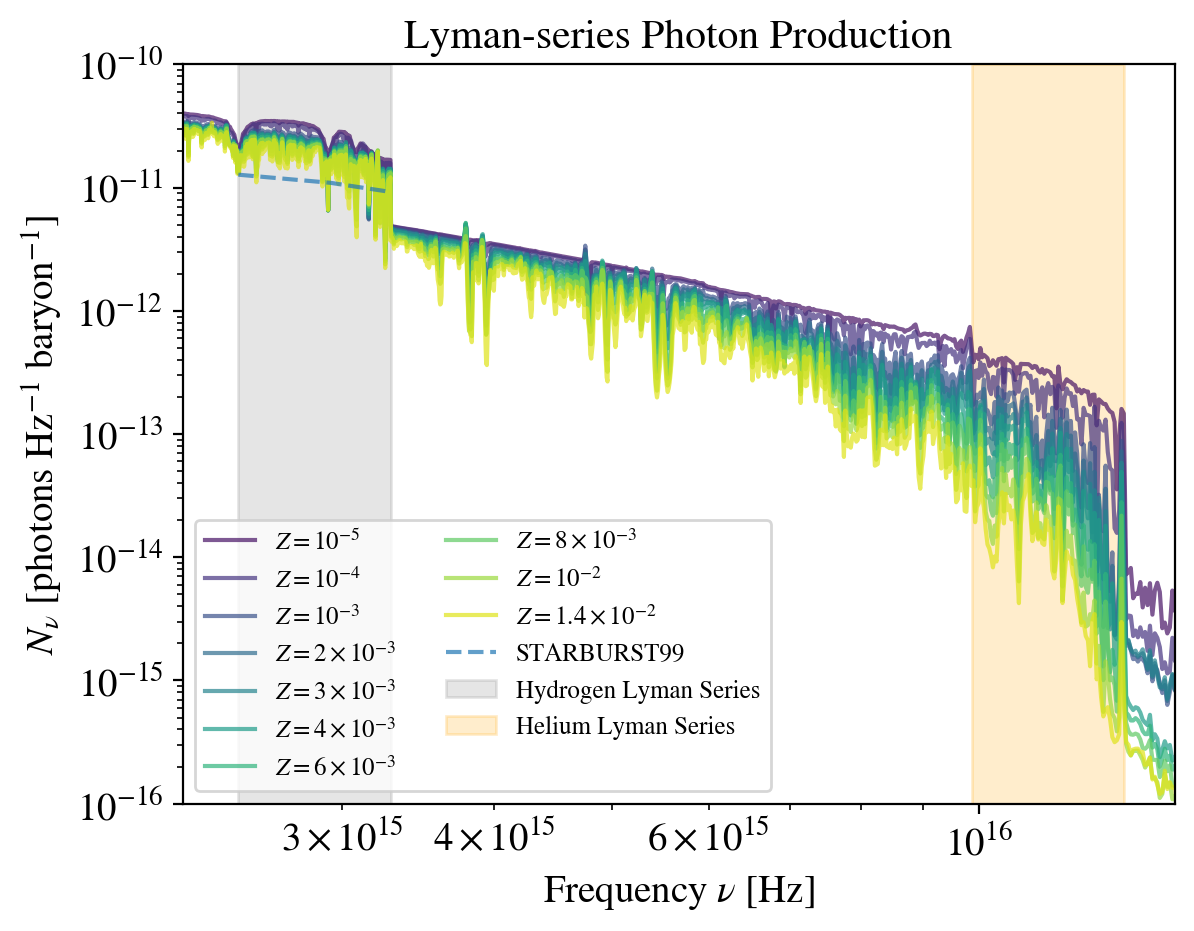

In [14]:
# ============================================================
# BPASS metallicity grid: lowest (1e-5) up to solar (1.4e-2)
# ============================================================
Z_GRID = [1.0e-5, 1.0e-4, 1.0e-3, 2.0e-3, 3.0e-3,
          4.0e-3, 6.0e-3, 8.0e-3, 1.0e-2, 1.4e-2]

def zlabel(Z):
    """Absolute metal mass fraction, e.g. 'Z = 2x10^-3'."""
    e = int(np.floor(np.log10(Z) + 1e-12))   # guard: log10(1e-3) = -3.0000...4
    m = round(Z / 10.0**e, 6)
    ms = f"{m:.1f}".rstrip('0').rstrip('.')
    return rf"$Z = 10^{{{e}}}$" if ms == "1" else rf"$Z = {ms}\times10^{{{e}}}$"

# Swap in this definition instead to label by solar ratio (Z_SUN = 1.4e-2):
# def zlabel(Z):
#     r = Z / 1.4e-2
#     if r >= 0.1:
#         return rf"${r:.2f}\,Z_\odot$"
#     e = int(np.floor(np.log10(r)))
#     return rf"${r/10**e:.1f}\times10^{{{e}}}\,Z_\odot$"

colors = plt.cm.viridis(np.linspace(0.05, 0.95, len(Z_GRID)))

for Z, c in zip(Z_GRID, colors):
    freq, N_nu = BPASS_SDF(Z)
    plt.loglog(freq, N_nu, alpha=0.7, linewidth=1.5, color=c, label=zlabel(Z))

# ==============
# STARBURST99
# ==============
alpha1 = 0.14
alpha2 = -0.5      # different slope after Lyβ
N_total = 9096
freq = np.linspace(NU_LYMAN_ALPHA, NU_LYMAN_LIMIT, 3000)
N_nu = STARBURST_SDF(freq, NU_LYMAN_ALPHA, NU_LYMAN_BETA, NU_LYMAN_LIMIT, alpha1, alpha2, N_total)
plt.loglog(freq, N_nu, alpha=0.7,  linewidth=1.5, linestyle="--", label="STARBURST99")

# ==============
# SHADED REGION
# ==============
plt.axvspan(NU_LYMAN_ALPHA, NU_LYMAN_LIMIT, color='gray', alpha=0.2, label='Hydrogen Lyman Series')
plt.axvspan(NU_LYMAN_ALPHA_He, NU_LYMAN_LIMIT_He, color='orange', alpha=0.2, label='Helium Lyman Series')

# Hydrogen
#plt.xlim(NU_LYMAN_ALPHA*0.95, NU_LYMAN_LIMIT*1.05) # Lyman series
#plt.ylim(1.0e-12, 1.0e-10)

# Helium
#plt.xlim(NU_LYMAN_ALPHA_He*0.95, NU_LYMAN_LIMIT_He*1.1) # Lyman series
#plt.ylim(1.0e-16, 1.0e-12)

# Both
plt.xlim(NU_LYMAN_ALPHA*0.9, NU_LYMAN_LIMIT_He*1.1) # Lyman series
plt.ylim(1.0e-16, 1.0e-10)

plt.legend(loc="lower left", fontsize=9, ncol=2)   # CHANGED from fontsize=12: 13 entries
plt.title(r'Lyman-series Photon Production', fontsize=15)
plt.xlabel(r'Frequency $\nu$ [Hz]', fontsize=14)
plt.ylabel(r'$N_\nu$ [photons Hz$^{-1}$ baryon$^{-1}$]',fontsize=14)

In [16]:
f, old = BPASS_SDF_old(1.0e-2)
f, new = BPASS_SDF(1.0e-2)
r = new / old
print(r.min(), r.max(), np.median(r))

Metallicity index: 8
Metallicity index: 8
1.1220184543019578 1.122018454301963 1.122018454301962


# Dummy Parts

In [ ]:
# Loop over all metallicities
for i_met in range(spec.N_metallicity):
    Z = spec.Metallicity[i_met]
    logZ = spec.LogMetallicity[i_met]
    
    # Start a new figure for this metallicity
    plt.figure(figsize=(12, 8))
    plt.title(f"BPASS Spectrum Evolution (Z = {Z:.1e}, Log Z = {logZ:.2f})", fontsize=16)

    # Loop over all ages within this metallicity
    for i_age in range(spec.N_age):
        age_gyr = spec.AgeGyr[i_age]
        
        # 3. Get the spectrum
        freq, L = spec.full_spectrum(i_age, i_met)
        
        # 4. Plot the spectrum
        # Label is based on age, formatted in millions or billions of years (Myr/Gyr)
        if age_gyr < 1.0:
            label = f"{age_gyr * 1000:.1f} Myr"
        else:
            label = f"{age_gyr:.2f} Gyr"
            
        # Plotting without explicit color (uses Matplotlib's default color cycle)
        plt.loglog(freq, L, alpha=0.7, linewidth=1.5, label=label)
        #plt.semilogy(freq, L, alpha=0.7, linewidth=1.5, label=label)

    # --- Finalize and Save Plot ---
    
    # Colorbar logic has been removed.

    plt.loglog(freq, epsilon_b(freq), color="red", alpha=1, linewidth=2.5, label="STARBURST")
    plt.xlabel("Frequency $\\nu$ (Hz)", fontsize=14)
    plt.ylabel("Emissivity $\\epsilon_b({\\nu})$ (photons/Hz/baryon)", fontsize=14)
    plt.xlim(2.466e15, 3.289e15) # Lyman series
    #plt.xlim(3.0e+13, 3.0e14)#2.466e15, 3.289e15)
    plt.ylim(1.0e-16, 1.0e-9)
    plt.grid(True, which="both", ls="--", alpha=0.5)
    
    # Place the legend outside the plot for better clarity since there are 34 lines
    plt.legend(title="Age", ncol=2, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=8) 
    plt.tight_layout()
    
    # Save the figure with a clear, unique filename
    filename = f"spectrum_Z_{Z:.1e}_test.png"
    plt.show()
    #plt.savefig(filename, dpi=300)
    #plt.close() # Close the figure to free memory before the next loop iteration

print(f"\nSuccessfully generated {spec.N_metallicity} plots.")
print("Check your directory for files named 'spectrum_Z_X.Xe-X.png'.")

In [ ]:
import h5py
import numpy as np
import os

def inspect_h5_structure(filepath):
    """
    Opens an HDF5 file and recursively inspects its groups, datasets, 
    and attributes, printing key metadata.
    """
    if not os.path.exists(filepath):
        print(f"ERROR: File not found at path: {filepath}")
        print("Please ensure the path is correct and the file is accessible.")
        return

    print("-" * 60)
    print(f"Attempting to open HDF5 file: {filepath}")
    print("-" * 60)
    
    try:
        with h5py.File(filepath, 'r') as f:
            
            def print_attrs(name, obj):
                """Helper function to print attributes of an object."""
                if obj.attrs:
                    print(f"  --> Attributes for '{name}':")
                    for key, val in obj.attrs.items():
                        # Truncate large array attributes for cleaner output
                        if isinstance(val, np.ndarray) and val.size > 5:
                            val_str = f"Array, shape={val.shape}, dtype={val.dtype}"
                        else:
                            val_str = str(val)
                            if len(val_str) > 80:
                                val_str = val_str[:77] + "..."
                                
                        print(f"      - {key}: {val_str}")

            def walk_structure(name, obj):
                """Recursive function to walk the file structure."""
                # Check if it is a Group
                if isinstance(obj, h5py.Group):
                    print(f"\n[GROUP] Path: {name}")
                    # Print attributes attached to the Group (e.g., Redshift, BoxSize)
                    print_attrs(name, obj)
                    
                # Check if it is a Dataset
                elif isinstance(obj, h5py.Dataset):
                    print(f"\n[DATASET] Path: {name}")
                    print(f"  Shape: {obj.shape}")
                    print(f"  Dtype: {obj.dtype}")
                    
                    # Print attributes attached to the Dataset (e.g., Units)
                    print_attrs(name, obj)

                    # Print a summary of the data if the dataset is small or 1D
                    if obj.ndim == 1 and obj.size < 50:
                        print(f"  Data Sample (Full 1D): {obj[:]}...")
                    elif obj.ndim > 0 and obj.shape[0] > 0:
                        # Print first few elements of the first dimension
                        sample_size = min(obj.shape[0], 5)
                        if obj.ndim == 1:
                            print(f"  Data Sample (First {sample_size} elements): {obj[:sample_size]}...")
                        else:
                            print(f"  Data Sample (First {sample_size} slices of dimension 0): Shape: {obj[:sample_size].shape}...")
                            
                return None

            # Start the recursive walk from the root ('/')
            f.visititems(walk_structure)
            
            print("\n" + "=" * 60)
            print("Inspection complete. Look for 'spectra', 'ages', 'metallicities', or 'WAVELENGTH' groups/datasets.")
            print("=" * 60)

    except Exception as e:
        print(f"\nAn unexpected error occurred: {e}")
        print("This might be due to a corrupted file or permissions issue.")

# The full path to your BPASS HDF5 file
file_to_inspect = "/orcd/data/mvogelsb/004/ozier/ZOOM_XL/sharedData/bpass_spectra_bin_chab100_v2.2.1.hdf5"

# Execute the inspection function
inspect_h5_structure(file_to_inspect)

In [ ]:
import numpy as np
import h5py
import os

# --- Define the Target Parameters ---
# The specific age and metallicity you want to target:
TARGET_AGE = 1.00000000e-03  # 1 Myr, in Gyr
TARGET_METALLICITY = 2.0e-03 # Z=0.002

# --- Simulate the HDF5 File (Since we cannot access your file) ---
# Replace this entire section with the actual loading of your HDF5 file.
FILE_PATH = 'bpass_spectra_dummy.hdf5'

# Your inspection showed the following shapes and data:
N_METALLICITY = 13
N_AGE = 34
N_FREQ = 100000
TOTAL_LNU_POINTS = N_METALLICITY * N_AGE * N_FREQ # 44200000

# Generating dummy data that mimics the structure you reported:
try:
    with h5py.File(FILE_PATH, 'w') as f:
        # Create the grid axes (as reported in your inspection)
        age_data = np.array([
            1.00000000e-03, 1.25892541e-03, 1.58489319e-03, 1.99526231e-03,
            2.51188643e-03, 3.16227766e-03, 3.98107171e-03, 5.01187234e-03,
            6.30957344e-03, 7.94328235e-03, 1.00000000e-02, 1.25892541e-02,
            1.58489319e-02, 1.99526231e-02, 2.51188643e-02, 3.16227766e-02,
            3.98107171e-02, 5.01187234e-02, 6.30957344e-02, 7.94328235e-02,
            1.00000000e-01, 1.25892541e-01, 1.58489319e-01, 1.99526231e-01,
            2.51188643e-01, 3.16227766e-01, 3.98107171e-01, 5.01187234e-01,
            6.30957344e-01, 7.94328235e-01, 1.00000000e+00, 1.25892541e+00,
            1.58489319e+00, 1.99526231e+00
        ])
        f.create_dataset('age', data=age_data)
        
        metallicity_data = np.array([
            1.0e-05, 1.0e-04, 1.0e-03, 2.0e-03, 3.0e-03, 4.0e-03, 6.0e-03,
            8.0e-03, 1.0e-02, 1.4e-02, 2.0e-02, 3.0e-02, 4.0e-02
        ])
        f.create_dataset('metallicity', data=metallicity_data)
        
        freq_data = np.linspace(2.99792458e+13, 2.99804450e+13, N_FREQ)
        f.create_dataset('freq', data=freq_data)
        
        # Create the flattened Lnu array (filled with sequential dummy data for testing)
        dummy_lnu = np.arange(TOTAL_LNU_POINTS, dtype=np.float64)
        f.create_dataset('Lnu', data=dummy_lnu)

except Exception as e:
    print(f"Error creating dummy HDF5 file: {e}")
    exit()

# --- Main Spectrum Extraction Logic ---

def get_bpass_spectrum(h5_filepath, target_Z, target_age):
    """
    Loads BPASS data from an HDF5 file, finds the indices for the target 
    metallicity and age, and extracts the corresponding spectrum (Lnu and freq).
    """
    try:
        with h5py.File(h5_filepath, 'r') as hf:
            # 1. Load the axis data
            Z_grid = hf['metallicity'][:]
            age_grid = hf['age'][:]
            freq_grid = hf['freq'][:]
            Lnu_flat = hf['Lnu'][:]
            
            # Get the size parameters for reshaping
            N_Z = len(Z_grid)
            N_AGE = len(age_grid)
            N_FREQ = len(freq_grid)
            
            # 2. Find the indices of the target parameters
            # Use np.where to find the index where the grid value matches the target value
            
            # Index for Metallicity (Z)
            z_index_match = np.where(Z_grid == target_Z)[0]
            if len(z_index_match) == 0:
                # If exact match is not found, you might want to interpolate or find the closest value
                print(f"Error: Metallicity {target_Z} not found in grid.")
                return None, None
            z_index = z_index_match[0]
            
            # Index for Age
            age_index_match = np.where(age_grid == target_age)[0]
            if len(age_index_match) == 0:
                print(f"Error: Age {target_age} not found in grid.")
                return None, None
            age_index = age_index_match[0]
            
            print(f"--- Indexing Results ---")
            print(f"Target Z={target_Z} found at Z-Index: {z_index}")
            print(f"Target Age={target_age} Gyr found at Age-Index: {age_index}")
            print(f"Total Frequency Bins: {N_FREQ}")
            
            # 3. Calculate the starting and ending index in the flattened array
            # The flattened array Lnu_flat is structured as:
            # [Z0_Age0_Freq0...99999, Z0_Age1_Freq0...99999, ..., Z1_Age0_Freq0...99999, ...]
            # The data is grouped by Metallicity (outer loop) then Age (inner loop) then Frequency.
            
            # Calculate the starting point of the desired slice:
            
            # Total points per Metallicity slice: N_AGE * N_FREQ
            points_per_Z = N_AGE * N_FREQ 
            
            # Total points per Age slice: N_FREQ
            points_per_Age = N_FREQ 
            
            # Starting index calculation:
            start_index = (z_index * points_per_Z) + (age_index * points_per_Age)
            end_index = start_index + N_FREQ
            
            # 4. Extract the spectrum
            spectrum_Lnu = Lnu_flat[start_index:end_index]
            
            print(f"\n--- Extraction Details ---")
            print(f"Calculated starting index in Lnu_flat: {start_index}")
            print(f"Calculated ending index in Lnu_flat: {end_index}")
            print(f"Extracted spectrum shape: {spectrum_Lnu.shape}")
            
            return freq_grid, spectrum_Lnu
            
    except Exception as e:
        print(f"An error occurred during HDF5 read: {e}")
        return None, None

# Run the extraction
freq, lnu = get_bpass_spectrum(FILE_PATH, TARGET_METALLICITY, TARGET_AGE)

if lnu is not None:
    print("\n--- Spectrum Extracted Successfully ---")
    print(f"First 5 Frequency values (Hz): {freq[:5]}")
    print(f"First 5 Lnu values (erg/s/Hz/Msun): {lnu[:5]}")
    
# Clean up dummy file
if os.path.exists(FILE_PATH):
    os.remove(FILE_PATH)

In [ ]:
freq

In [ ]:
lnu

In [ ]:
import sys
import matplotlib.pyplot as plt
%matplotlib inline

plt.plot(freq, lnu)
plt.xscale("log")
plt.yscale("log")